# 06 Transformer Model - PubMedBERT

This notebook fine-tunes **PubMedBERT** on the combined **FakeHealth + HealthFact** binary misinformation dataset, using the **exact same** split strategy, hyperparameters, and evaluation pipeline as `04_transformer_biobert.ipynb` so that results are directly comparable.


## Why PubMedBERT?

Unlike BioBERT — which was initialised from general BERT and then continued pre-training on biomedical text — **PubMedBERT** (`microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext`) was pre-trained **from scratch** exclusively on PubMed abstracts and full-text articles. This means its vocabulary and representations are fully specialised to biomedical and clinical language, with no contamination from general-domain text.

Key differences vs BioBERT:

| Property | BioBERT | PubMedBERT |
|---|---|---|
| Initialisation | General BERT | Scratch |
| Pre-training data | PubMed + PMC | PubMed abstracts + full-text |
| Casing | Cased | **Uncased** |
| Vocabulary | General BERT vocab | Domain-specific vocab |

Because PubMedBERT is **uncased**, the tokenizer will lowercase all input text automatically — no manual pre-processing change is needed.


## CPU Training Note

This notebook is configured for a **CPU-only** environment, matching the conservative settings used for BioBERT:

- `num_train_epochs = 3 to 5
- 
- `per_device_train_batch_size = 4`
- `gradient_accumulation_steps = 2`
- `max_length = 256`

Training will be slow on CPU. If a GPU is available, set `use_cpu=False` (or remove the flag) in `TrainingArguments` and increase `per_device_train_batch_size` to `16` for much faster runs.


## Model Download
- `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext`


In [1]:
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


C:\Users\ribam\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
DATA_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
MODEL_DIR = PROJECT_ROOT / 'model' / 'pubmedbert_fakehealth_healthfact'
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'pubmedbert_fakehealth_healthfact'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
MAX_LENGTH = 256
NUM_EPOCHS = 5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 2e-5
RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Model:', MODEL_NAME)


Device: cpu
Model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


In [4]:
df = pd.read_csv(DATA_PATH)
TEXT_COL = "model_text" if "model_text" in df.columns else "text"
preview_cols = list(dict.fromkeys(["dataset", "split", "record_id", "label", "text", TEXT_COL]))

print("Shape:", df.shape)
print("Dataset counts:", df["dataset"].value_counts().to_dict())
print("Label counts:", df["label"].value_counts().to_dict())
print("Text column:", TEXT_COL)
df[preview_cols].head(3)


Shape: (12273, 16)
Dataset counts: {'healthfact': 10075, 'fakehealth': 2156, 'curated_health_claims': 42}
Label counts: {1: 7563, 0: 4710}
Text column: model_text


,dataset,split,record_id,label,text,model_text
0,fakehealth,release,news_reviews_00000,0,"MADISON, Wis. -- More than 700 million adults ...",Tiny implantable device short-circuits hunger ...
1,fakehealth,release,news_reviews_00001,1,"Wilmington, DE, December 17, 2018 - The CRISPR...",Scientists report CRISPR restores effectivenes...
2,fakehealth,release,news_reviews_00002,0,About 3 million people in the US are diagnosed...,Probiotics could help millions of patients suf...


## Split Strategy

Identical to `04_transformer_biobert.ipynb` so results are directly comparable:

- Keep the original `healthfact` `train / dev / test` splits as-is.
- Create a stratified 70 / 15 / 15 split for `FakeHealth` (which has no predefined split).
- Merge the corresponding partitions.

`RANDOM_STATE = 42` is locked in both notebooks, so the exact same rows land in each split.


In [5]:
VALID_SPLITS = {"train", "dev", "test"}
CURATED_TRAIN_REPEAT = 4


def make_train_dev_test(data: pd.DataFrame, random_state: int = 42):
    # Respect existing train/dev/test splits and split unsplit datasets reproducibly.
    data = data.copy()
    data["split"] = data["split"].fillna("").astype(str).str.lower().str.strip()

    fixed = data[data["split"].isin(VALID_SPLITS)].copy()
    unsplit = data[~data["split"].isin(VALID_SPLITS)].copy()

    split_frames = {
        "train": [fixed[fixed["split"] == "train"]],
        "dev": [fixed[fixed["split"] == "dev"]],
        "test": [fixed[fixed["split"] == "test"]],
    }

    for dataset_name, group in unsplit.groupby("dataset"):
        group = group.copy()
        if len(group) < 10 or group["label"].nunique() < 2:
            group["split"] = "train"
            split_frames["train"].append(group)
            continue

        train_part, temp_part = train_test_split(
            group,
            test_size=0.30,
            stratify=group["label"],
            random_state=random_state,
        )
        dev_part, test_part = train_test_split(
            temp_part,
            test_size=0.50,
            stratify=temp_part["label"],
            random_state=random_state,
        )
        train_part = train_part.copy()
        dev_part = dev_part.copy()
        test_part = test_part.copy()
        train_part["split"] = "train"
        dev_part["split"] = "dev"
        test_part["split"] = "test"
        split_frames["train"].append(train_part)
        split_frames["dev"].append(dev_part)
        split_frames["test"].append(test_part)

    train_df = pd.concat(split_frames["train"], ignore_index=True)
    dev_df = pd.concat(split_frames["dev"], ignore_index=True)
    test_df = pd.concat(split_frames["test"], ignore_index=True)

    curated_train = train_df[train_df["dataset"] == "curated_health_claims"]
    if not curated_train.empty and CURATED_TRAIN_REPEAT > 1:
        train_df = pd.concat(
            [train_df] + [curated_train.copy() for _ in range(CURATED_TRAIN_REPEAT - 1)],
            ignore_index=True,
        )

    return train_df.sample(frac=1, random_state=random_state).reset_index(drop=True), dev_df, test_df


train_df, dev_df, test_df = make_train_dev_test(df, random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
print("Text column:", TEXT_COL)
print("Train labels:", train_df["label"].value_counts().to_dict())
print("Dev labels:", dev_df["label"].value_counts().to_dict())
print("Test labels:", test_df["label"].value_counts().to_dict())
print("Train datasets:", train_df["dataset"].value_counts().to_dict())


Train shape: (9708, 16)
Dev shape: (1338, 16)
Test shape: (1317, 16)
Text column: model_text
Train labels: {1: 6003, 0: 3705}
Dev labels: {1: 817, 0: 521}
Test labels: {1: 788, 0: 529}
Train datasets: {'healthfact': 8079, 'fakehealth': 1509, 'curated_health_claims': 120}


In [6]:
train_df.to_csv(OUTPUT_DIR / 'train_split.csv', index=False)
dev_df.to_csv(OUTPUT_DIR / 'dev_split.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test_split.csv', index=False)
print('Saved train/dev/test split files to', OUTPUT_DIR)


Saved train/dev/test split files to C:\Users\ribam\Desktop\Reseach\Dataset\output\pubmedbert_fakehealth_healthfact


## Load Tokenizer and Model

PubMedBERT uses an **uncased** tokenizer — the tokenizer itself handles lowercasing, so no manual text pre-processing change is needed compared to BioBERT.


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'misinformation', 1: 'reliable'},
    label2id={'misinformation': 0, 'reliable': 1},
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Dataset Class and Data Collator


In [8]:
class HealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
        )
        encoded['labels'] = int(self.labels[idx])
        return encoded


In [9]:
train_dataset = HealthDataset(train_df[TEXT_COL], train_df["label"], tokenizer, MAX_LENGTH)
dev_dataset = HealthDataset(dev_df[TEXT_COL], dev_df["label"], tokenizer, MAX_LENGTH)
test_dataset = HealthDataset(test_df[TEXT_COL], test_df["label"], tokenizer, MAX_LENGTH)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

len(train_dataset), len(dev_dataset), len(test_dataset)


(9708, 1338, 1317)

## Metrics Function


In [10]:
def metrics_from_predictions(y_true, y_pred, prefix="eval"):
    reliable_precision, reliable_recall, reliable_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    misinfo_precision, misinfo_recall, misinfo_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=0, zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        f"{prefix}_accuracy": float(accuracy_score(y_true, y_pred)),
        f"{prefix}_precision": float(reliable_precision),
        f"{prefix}_recall": float(reliable_recall),
        f"{prefix}_f1": float(reliable_f1),
        f"{prefix}_macro_precision": float(macro_precision),
        f"{prefix}_macro_recall": float(macro_recall),
        f"{prefix}_macro_f1": float(macro_f1),
        f"{prefix}_misinformation_precision": float(misinfo_precision),
        f"{prefix}_misinformation_recall": float(misinfo_recall),
        f"{prefix}_misinformation_f1": float(misinfo_f1),
        f"{prefix}_reliable_precision": float(reliable_precision),
        f"{prefix}_reliable_recall": float(reliable_recall),
        f"{prefix}_reliable_f1": float(reliable_f1),
    }


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metrics = metrics_from_predictions(labels, predictions, prefix="")
    return {key.lstrip("_"): value for key, value in metrics.items()}


## Training Arguments

All hyperparameters are identical to BioBERT to ensure a fair comparison.


In [11]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    do_train=True,
    do_eval=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=3,
    report_to='none',
    seed=RANDOM_STATE,
    use_cpu=not torch.cuda.is_available(),
    remove_unused_columns=True,
    group_by_length=True,
)


## Train


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


C:\Users\ribam\AppData\Local\Temp\ipykernel_40772\556424010.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro Precision,Macro Recall,Macro F1,Misinformation Precision,Misinformation Recall,Misinformation F1,Reliable Precision,Reliable Recall,Reliable F1
1,0.532100,0.614363,0.729447,0.723697,0.900857,0.802617,0.735680,0.680755,0.686344,0.747664,0.460653,0.570071,0.723697,0.900857,0.802617
2,0.460500,0.511988,0.736921,0.743455,0.869033,0.801354,0.732041,0.699392,0.705987,0.720627,0.529750,0.610619,0.743455,0.869033,0.801354
3,0.299400,0.584458,0.756353,0.794718,0.810282,0.802424,0.743894,0.741033,0.742343,0.693069,0.671785,0.682261,0.794718,0.810282,0.802424
4,0.193000,0.796770,0.757100,0.804455,0.795594,0.800000,0.744681,0.746165,0.745385,0.684906,0.696737,0.690771,0.804455,0.795594,0.800000
5,0.244300,1.056582,0.760837,0.801944,0.807834,0.804878,0.748545,0.747487,0.747999,0.695146,0.687140,0.691120,0.801944,0.807834,0.804878


TrainOutput(global_step=6070, training_loss=0.35576470656292836, metrics={'train_runtime': 14786.1529, 'train_samples_per_second': 3.283, 'train_steps_per_second': 0.411, 'total_flos': 1430859585701280.0, 'train_loss': 0.35576470656292836, 'epoch': 5.0})

## Evaluate on Dev and Test Sets


In [13]:
checkpoint_root = OUTPUT_DIR / "checkpoints"
checkpoint_dirs = sorted(checkpoint_root.glob("checkpoint-*"))

print("Found checkpoints:")
for checkpoint_dir in checkpoint_dirs:
    print(" -", checkpoint_dir.name)

if not checkpoint_dirs:
    raise FileNotFoundError(f"No checkpoints found in {checkpoint_root}. Run the training cell first.")


def predict_with_checkpoint(checkpoint_dir, frame, batch_size=16, return_probs=False):
    model_for_eval = AutoModelForSequenceClassification.from_pretrained(str(checkpoint_dir))
    model_for_eval.to(DEVICE)
    model_for_eval.eval()

    texts = frame[TEXT_COL].astype(str).tolist()
    preds = []
    probs_all = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        with torch.no_grad():
            logits = model_for_eval(**inputs).logits

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds.extend(np.argmax(probs, axis=-1).tolist())
        probs_all.append(probs)

    preds = np.array(preds)
    if return_probs:
        return preds, np.vstack(probs_all)
    return preds


checkpoint_results = []

for checkpoint_dir in checkpoint_dirs:
    dev_pred = predict_with_checkpoint(checkpoint_dir, dev_df)
    dev_y = dev_df["label"].to_numpy()

    _, _, dev_macro_f1, _ = precision_recall_fscore_support(
        dev_y,
        dev_pred,
        average="macro",
        zero_division=0,
    )
    dev_acc = accuracy_score(dev_y, dev_pred)

    checkpoint_results.append(
        {
            "checkpoint": checkpoint_dir,
            "dev_accuracy": dev_acc,
            "dev_macro_f1": dev_macro_f1,
        }
    )

checkpoint_results = sorted(checkpoint_results, key=lambda row: row["dev_macro_f1"], reverse=True)

print("\nCheckpoint ranking by dev macro-F1:")
for row in checkpoint_results:
    print(
        row["checkpoint"].name,
        "acc=", round(row["dev_accuracy"], 4),
        "macro_f1=", round(row["dev_macro_f1"], 4),
    )

BEST_MODEL_CHECKPOINT = checkpoint_results[0]["checkpoint"]
print("\nUsing best checkpoint:", BEST_MODEL_CHECKPOINT)

eval_model = AutoModelForSequenceClassification.from_pretrained(str(BEST_MODEL_CHECKPOINT))
eval_model.to(DEVICE)
eval_model.eval()

dev_pred_labels, dev_probabilities = predict_with_checkpoint(
    BEST_MODEL_CHECKPOINT,
    dev_df,
    return_probs=True,
)
test_pred_labels, test_probabilities = predict_with_checkpoint(
    BEST_MODEL_CHECKPOINT,
    test_df,
    return_probs=True,
)

dev_metrics = metrics_from_predictions(dev_df["label"].to_numpy(), dev_pred_labels, prefix="eval")
test_metrics = metrics_from_predictions(test_df["label"].to_numpy(), test_pred_labels, prefix="eval")

print("--- Dev Metrics from explicit best checkpoint ---")
for key, value in dev_metrics.items():
    print(f"  {key}: {value}")

print("\n--- Test Metrics from explicit best checkpoint ---")
for key, value in test_metrics.items():
    print(f"  {key}: {value}")


Found checkpoints:
 - checkpoint-3642
 - checkpoint-4856
 - checkpoint-6070

Checkpoint ranking by dev macro-F1:
checkpoint-6070 acc= 0.7608 macro_f1= 0.748
checkpoint-4856 acc= 0.7571 macro_f1= 0.7454
checkpoint-3642 acc= 0.7564 macro_f1= 0.7423

Using best checkpoint: C:\Users\ribam\Desktop\Reseach\Dataset\output\pubmedbert_fakehealth_healthfact\checkpoints\checkpoint-6070
--- Dev Metrics from explicit best checkpoint ---
  eval_accuracy: 0.7608370702541106
  eval_precision: 0.8019441069258809
  eval_recall: 0.8078335373317014
  eval_f1: 0.8048780487804879
  eval_macro_precision: 0.748544868996921
  eval_macro_recall: 0.7474868262474246
  eval_macro_f1: 0.7479988699500895
  eval_misinformation_precision: 0.6951456310679611
  eval_misinformation_recall: 0.6871401151631478
  eval_misinformation_f1: 0.6911196911196911
  eval_reliable_precision: 0.8019441069258809
  eval_reliable_recall: 0.8078335373317014
  eval_reliable_f1: 0.8048780487804879

--- Test Metrics from explicit best checkp

## Test Set Classification Report


In [14]:
print(classification_report(
    test_df["label"],
    test_pred_labels,
    labels=[0, 1],
    target_names=["misinformation", "reliable"],
    digits=4,
))


                precision    recall  f1-score   support

misinformation     0.6637    0.7164    0.6891       529
      reliable     0.7989    0.7563    0.7771       788

      accuracy                         0.7403      1317
     macro avg     0.7313    0.7364    0.7331      1317
  weighted avg     0.7446    0.7403    0.7417      1317



## Confusion Matrix


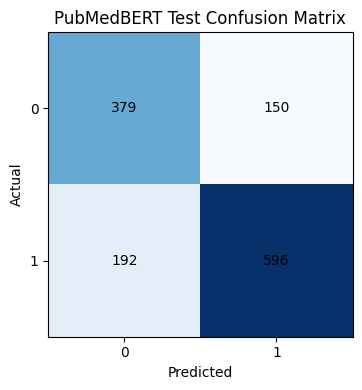

In [15]:
os.environ['MPLCONFIGDIR'] = str(OUTPUT_DIR / '.matplotlib')
(OUTPUT_DIR / '.matplotlib').mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['label'], test_pred_labels)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_title('PubMedBERT Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pubmedbert_confusion_matrix.png', dpi=150)
plt.show()


## Save Model, Metrics, and Predictions


In [16]:
eval_model.save_pretrained(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

metrics = {
    "model_name": MODEL_NAME,
    "text_column": TEXT_COL,
    "max_length": MAX_LENGTH,
    "num_epochs": NUM_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "device": str(DEVICE),
    "train_rows": int(len(train_df)),
    "dev_rows": int(len(dev_df)),
    "test_rows": int(len(test_df)),
    "curated_train_repeat": CURATED_TRAIN_REPEAT,
    "best_model_checkpoint": str(BEST_MODEL_CHECKPOINT) if BEST_MODEL_CHECKPOINT is not None else None,
    "metrics_source": "explicit_best_checkpoint_predictions",
    "dev_metrics": {k: float(v) for k, v in dev_metrics.items() if isinstance(v, (int, float))},
    "test_metrics": {k: float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
}

(OUTPUT_DIR / "pubmedbert_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

output_cols = [c for c in ["dataset", "split", "record_id", "label", "text", "model_text"] if c in test_df.columns]
prediction_df = test_df[output_cols].copy()
prediction_df["prediction"] = test_pred_labels
prediction_df["prob_class_0"] = test_probabilities[:, 0]
prediction_df["prob_class_1"] = test_probabilities[:, 1]
prediction_df.to_csv(OUTPUT_DIR / "pubmedbert_test_predictions.csv", index=False)

print("Saved best checkpoint model to:", MODEL_DIR)
print("Saved outputs to:", OUTPUT_DIR)
metrics


Saved best checkpoint model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\pubmedbert_fakehealth_healthfact
Saved outputs to: C:\Users\ribam\Desktop\Reseach\Dataset\output\pubmedbert_fakehealth_healthfact


{'model_name': 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext',
 'text_column': 'model_text',
 'max_length': 256,
 'num_epochs': 5,
 'train_batch_size': 4,
 'eval_batch_size': 4,
 'gradient_accumulation_steps': 2,
 'learning_rate': 2e-05,
 'device': 'cpu',
 'train_rows': 9708,
 'dev_rows': 1338,
 'test_rows': 1317,
 'curated_train_repeat': 4,
 'best_model_checkpoint': 'C:\\Users\\ribam\\Desktop\\Reseach\\Dataset\\output\\pubmedbert_fakehealth_healthfact\\checkpoints\\checkpoint-6070',
 'metrics_source': 'explicit_best_checkpoint_predictions',
 'dev_metrics': {'eval_accuracy': 0.7608370702541106,
  'eval_precision': 0.8019441069258809,
  'eval_recall': 0.8078335373317014,
  'eval_f1': 0.8048780487804879,
  'eval_macro_precision': 0.748544868996921,
  'eval_macro_recall': 0.7474868262474246,
  'eval_macro_f1': 0.7479988699500895,
  'eval_misinformation_precision': 0.6951456310679611,
  'eval_misinformation_recall': 0.6871401151631478,
  'eval_misinformation_f1': 0.6911196

## Next Step

With PubMedBERT results saved, the next notebook is:

- **`07_model_comparison_three_way.ipynb`** — extend `05_model_comparison_and_error_analysis` to include PubMedBERT alongside TF-IDF + Logistic Regression and BioBERT for a three-way comparison table, bar chart, per-dataset breakdown, and updated error-analysis buckets.
